## Load Dependencies

In [19]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.feature_extraction.text import CountVectorizer
from xgboost import XGBClassifier

# Download stopwords if not already downloaded
# nltk.download('stopwords')

## Load Data

In [20]:
df=pd.read_csv("../data/spam.csv",encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [21]:
df=df[["v1","v2"]]
df.rename(columns={"v1":"label","v2":"message"},inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


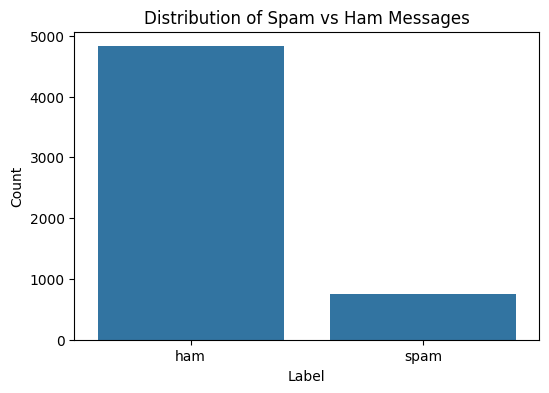

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Label')
plt.ylabel('Count')

plt.show()

## Preprocessing

In [23]:
stopwords_set=set(stopwords.words("english"))

def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^0-9a-zA-Z]"," ",text)
    text=re.sub(r"\s+"," ",text)
    text=" ".join(word for word in text.split() if word not in stopwords_set)
    return text

In [24]:
df["cleaned_text"]=df["message"].apply(clean_text)
df["label"]=df["label"].map({"ham":0,"spam":1})
df.head()

,label,message,cleaned_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


## Splitting the Input

In [25]:
X=df["cleaned_text"]
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
tfidf=CountVectorizer(max_features=5000,stop_words="english",ngram_range=(1,2))
X_train_vec=tfidf.fit_transform(X_train)
X_test_vec=tfidf.transform(X_test)

## Architecture

In [27]:
xgb=XGBClassifier(n_estimators=100,max_depth=6,random_state=42)
xgb.fit(X_train_vec, y_train,eval_set=[(X_test_vec,y_test)],verbose=False)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Final Test Accuracy: 97.3991%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       965
        Spam       0.95      0.85      0.90       150

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:


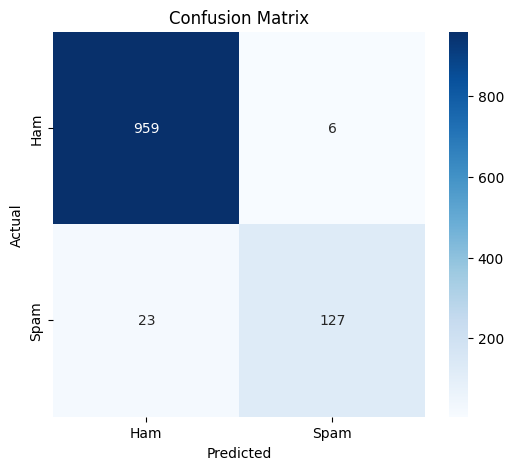

In [28]:
xgb_y_pred=xgb.predict(X_test_vec)

print(f"Final Test Accuracy: {accuracy_score(y_test,xgb_y_pred)*100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test,xgb_y_pred,target_names=['Ham','Spam']))
print("\nConfusion Matrix:")
conf_matrix=confusion_matrix(y_test,xgb_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
def predict_message(message, model, vectorizer):
    message_tfidf=vectorizer.transform([message])
    probabilities=model.predict_proba(message_tfidf)[0]
    prediction=model.predict(message_tfidf)[0]
    label="SPAM" if prediction==1 else "HAM"
    ham_percentage=probabilities[0]*100
    spam_percentage=probabilities[1]*100
    return label,spam_percentage,ham_percentage

# Test messages
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: http://fake-link.com",
    "Thanks for the movie recommendation, I really enjoyed it!",
    "FREE entry for a Disney holiday! Text WIN to 80085 now!",
    "Can you pick up some milk on your way home?"
]

print("Testing custom messages:")
print("-" * 60)
for msg in test_messages:
    label, spam_pct,ham_pct = predict_message(msg,xgb,tfidf)
    print(f"Message: {msg}...")
    print(f"Prediction: {label} (Confidence: {spam_pct:.1f}% Spam | {ham_pct:.1f}% Ham)\n")

Testing custom messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone. Click here to claim now!...
Prediction: SPAM (Confidence: 90.4% Spam | 9.6% Ham)

Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: HAM (Confidence: 0.3% Spam | 99.7% Ham)

Message: URGENT: Your account has been compromised. Verify now: http://fake-link.com...
Prediction: SPAM (Confidence: 94.4% Spam | 5.6% Ham)

Message: Thanks for the movie recommendation, I really enjoyed it!...
Prediction: HAM (Confidence: 1.3% Spam | 98.7% Ham)

Message: FREE entry for a Disney holiday! Text WIN to 80085 now!...
Prediction: SPAM (Confidence: 96.5% Spam | 3.5% Ham)

Message: Can you pick up some milk on your way home?...
Prediction: HAM (Confidence: 0.3% Spam | 99.7% Ham)

